# Rainfall Prediction Classifier

## Final Project — WeatherTech Inc.

**Objective:** Build a machine learning classifier that predicts whether it will rain tomorrow based on historical weather data.

### Project Tasks
1. **Explore and Prepare the Dataset** — Feature engineering and cleaning
2. **Build a Classifier Pipeline** — Model selection, training, and optimization
3. **Evaluate Model Performance** — Interpret metrics and visualizations

---
## 1. Import Libraries

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay
)

print('All libraries imported successfully.')

All libraries imported successfully.


---
## 2. Load the Dataset

In [2]:
# Load the dataset
# The Weather Australia dataset is a well-known public dataset for rainfall prediction
url = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillUp/labs/ML-FinalAssignment/Weather_Data.csv'
df = pd.read_csv(url)

print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (3271, 22)


,Date,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2/1/2008,19.5,22.4,15.6,6.2,0.0,W,41,S,SSW,...,92,84,1017.6,1017.4,8,8,20.7,20.9,Yes,Yes
1,2/2/2008,19.5,25.6,6.0,3.4,2.7,W,41,W,E,...,83,73,1017.9,1016.4,7,7,22.4,24.8,Yes,Yes
2,2/3/2008,21.6,24.5,6.6,2.4,0.1,W,41,ESE,ESE,...,88,86,1016.7,1015.6,7,8,23.5,23.0,Yes,Yes
3,2/4/2008,20.2,22.8,18.8,2.2,0.0,W,41,NNE,E,...,83,90,1014.2,1011.8,8,8,21.4,20.9,Yes,Yes
4,2/5/2008,19.7,25.7,77.4,4.8,0.0,W,41,NNE,W,...,88,74,1008.3,1004.8,8,8,22.5,25.5,Yes,Yes


---
## 3. Explore and Prepare the Dataset
### 3.1 Initial Data Exploration

In [3]:
# Basic information about the dataset
print('=== Dataset Info ===')
print(df.info())
print('\n=== Dataset Shape ===')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')
print('\n=== Column Data Types ===')
print(df.dtypes)

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3271 entries, 0 to 3270
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           3271 non-null   object 
 1   MinTemp        3271 non-null   float64
 2   MaxTemp        3271 non-null   float64
 3   Rainfall       3271 non-null   float64
 4   Evaporation    3271 non-null   float64
 5   Sunshine       3271 non-null   float64
 6   WindGustDir    3271 non-null   object 
 7   WindGustSpeed  3271 non-null   int64  
 8   WindDir9am     3271 non-null   object 
 9   WindDir3pm     3271 non-null   object 
 10  WindSpeed9am   3271 non-null   int64  
 11  WindSpeed3pm   3271 non-null   int64  
 12  Humidity9am    3271 non-null   int64  
 13  Humidity3pm    3271 non-null   int64  
 14  Pressure9am    3271 non-null   float64
 15  Pressure3pm    3271 non-null   float64
 16  Cloud9am       3271 non-null   int64  
 17  Cloud3pm       3271 non-null   

In [4]:
# Statistical summary
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,3271.000000,3271.000000,3271.000000,3271.000000,3271.000000,3271.000000,3271.000000,3271.000000,3271.000000,3271.000000,3271.000000,3271.000000,3271.000000,3271.000000,3271.000000,3271.000000
mean,14.877102,23.005564,3.342158,5.175787,7.168970,41.476307,15.077041,19.294405,68.243962,54.698563,1018.334424,1016.003085,4.318557,4.176093,17.821461,21.543656
std,4.554710,4.483752,9.917746,2.757684,3.815966,10.806951,7.043825,7.453331,15.086127,16.279241,7.020090,7.019915,2.526923,2.411274,4.894316,4.297053
min,4.300000,11.700000,0.000000,0.000000,0.000000,17.000000,0.000000,0.000000,19.000000,10.000000,986.700000,989.800000,0.000000,0.000000,6.400000,10.200000
25%,11.000000,19.600000,0.000000,3.200000,4.250000,35.000000,11.000000,15.000000,58.000000,44.000000,1013.700000,1011.300000,2.000000,2.000000,13.800000,18.400000
50%,14.900000,22.800000,0.000000,4.800000,8.300000,41.000000,15.000000,19.000000,69.000000,56.000000,1018.600000,1016.300000,5.000000,4.000000,18.200000,21.300000
75%,18.800000,26.000000,1.400000,7.000000,10.200000,44.000000,20.000000,24.000000,80.000000,64.000000,1023.100000,1020.800000,7.000000,7.000000,21.700000,24.500000
max,27.600000,45.800000,119.400000,18.400000,13.600000,96.000000,54.000000,57.000000,100.000000,99.000000,1039.000000,1036.700000,9.000000,8.000000,36.500000,44.700000


In [5]:
# Check for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print('=== Missing Values ===')
print(missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False))

=== Missing Values ===
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


=== Target Variable (RainTomorrow) Distribution ===
RainTomorrow
No     2422
Yes     849
Name: count, dtype: int64

Class balance: RainTomorrow
No     0.74
Yes    0.26
Name: proportion, dtype: float64


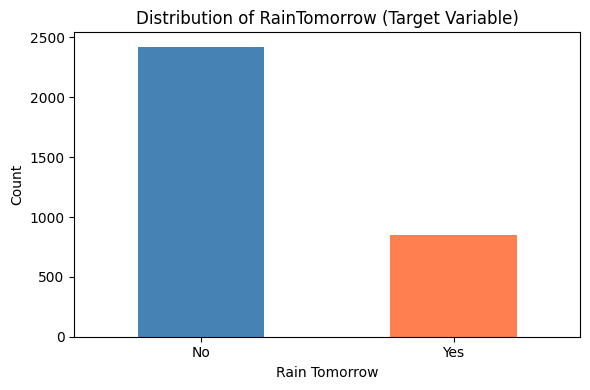

In [6]:
# Target variable distribution
print('=== Target Variable (RainTomorrow) Distribution ===')
print(df['RainTomorrow'].value_counts())
print(f'\nClass balance: {df["RainTomorrow"].value_counts(normalize=True).round(3)}')

fig, ax = plt.subplots(figsize=(6, 4))
df['RainTomorrow'].value_counts().plot(kind='bar', color=['steelblue', 'coral'], ax=ax)
ax.set_title('Distribution of RainTomorrow (Target Variable)')
ax.set_xlabel('Rain Tomorrow')
ax.set_ylabel('Count')
ax.set_xticklabels(['No', 'Yes'], rotation=0)
plt.tight_layout()
plt.show()

### 3.2 Data Visualization

In [7]:
# Select numeric columns for exploration
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f'Numeric columns: {numeric_cols}')

Numeric columns: ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']


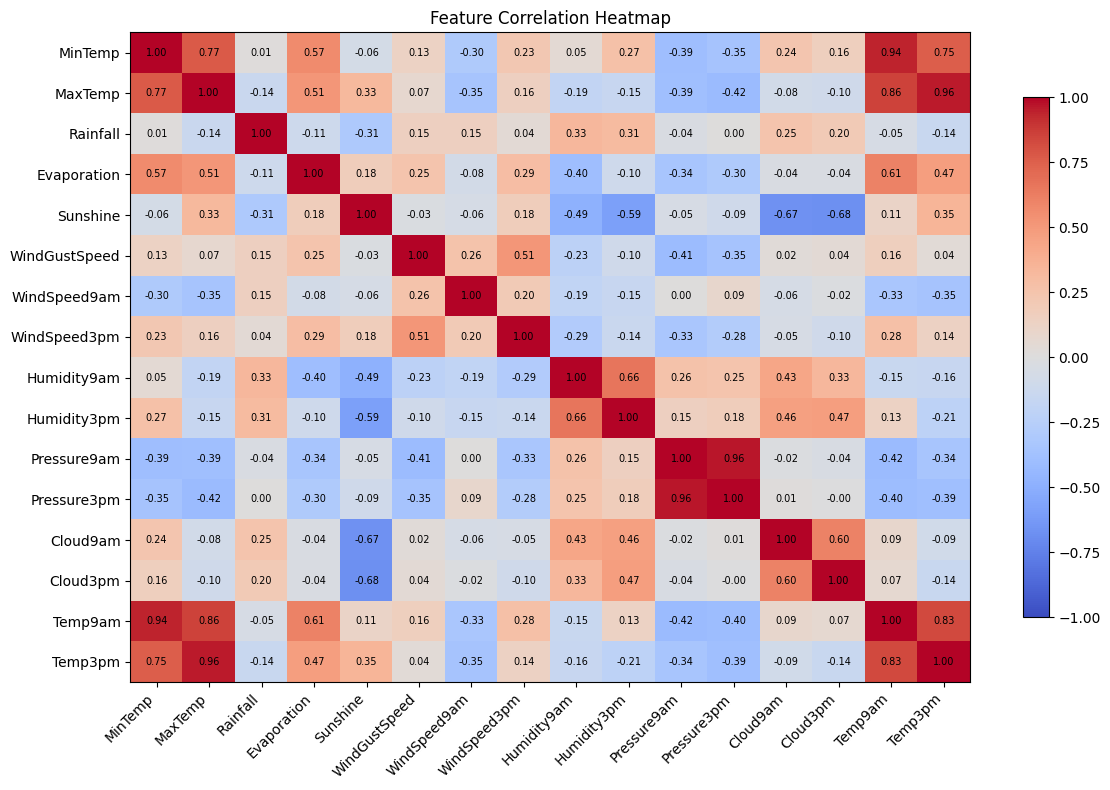

In [8]:
# Correlation heatmap using matplotlib
correlation_matrix = df[numeric_cols].corr()
fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(correlation_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_yticks(range(len(correlation_matrix.columns)))
ax.set_xticklabels(correlation_matrix.columns, rotation=45, ha='right')
ax.set_yticklabels(correlation_matrix.columns)
# Annotate cells
for i in range(len(correlation_matrix)):
    for j in range(len(correlation_matrix)):
        ax.text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}',
                ha='center', va='center', fontsize=7)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

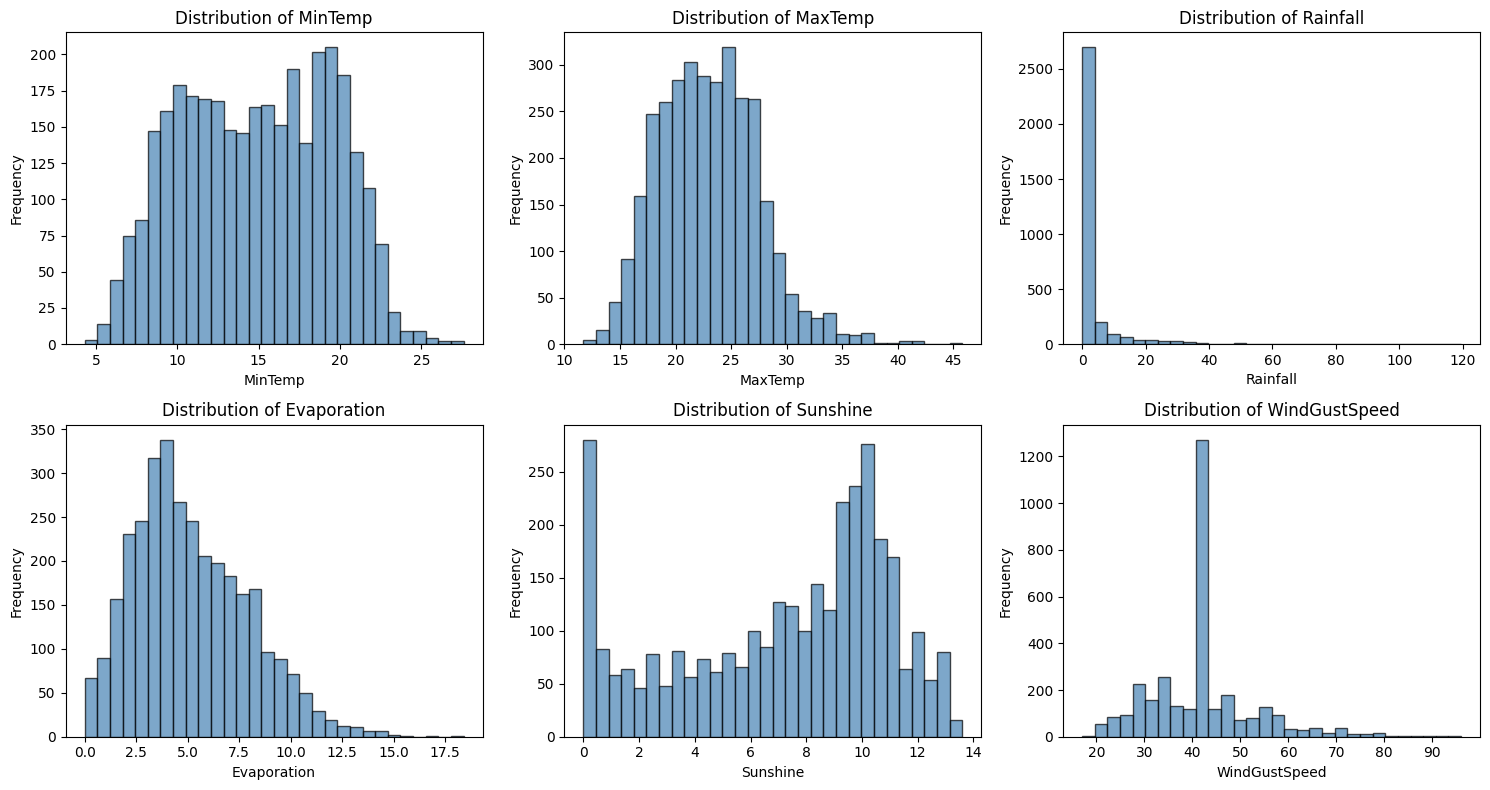

In [9]:
# Distribution of key numeric features
features_to_plot = [col for col in numeric_cols if col != 'RainTomorrow'][:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for idx, col in enumerate(features_to_plot):
    row, col_idx = idx // 3, idx % 3
    axes[row, col_idx].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    axes[row, col_idx].set_title(f'Distribution of {col}')
    axes[row, col_idx].set_xlabel(col)
    axes[row, col_idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### 3.3 Data Cleaning and Preprocessing

In [10]:
# Create a working copy
data = df.copy()

# Convert the target variable to binary (if it's categorical)
if data['RainTomorrow'].dtype == 'object':
    data['RainTomorrow'] = data['RainTomorrow'].map({'No': 0, 'Yes': 1})

# Drop rows where target is null
data.dropna(subset=['RainTomorrow'], inplace=True)

print(f'Shape after dropping null targets: {data.shape}')

Shape after dropping null targets: (3271, 22)


In [11]:
# Identify categorical and numeric columns
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()

# Remove target from numeric cols list
if 'RainTomorrow' in numeric_cols:
    numeric_cols.remove('RainTomorrow')

# Remove date column if present
if 'Date' in categorical_cols:
    categorical_cols.remove('Date')
    data.drop('Date', axis=1, inplace=True)

print(f'Categorical columns: {categorical_cols}')
print(f'Numeric columns: {numeric_cols}')

Categorical columns: ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']
Numeric columns: ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']


In [12]:
# Handle missing values in numeric columns — fill with median
for col in numeric_cols:
    data[col].fillna(data[col].median(), inplace=True)

# Handle missing values in categorical columns — fill with mode
for col in categorical_cols:
    data[col].fillna(data[col].mode()[0], inplace=True)

print(f'Missing values remaining: {data.isnull().sum().sum()}')

Missing values remaining: 0


### 3.4 Feature Engineering

In [13]:
# Encode categorical variables using Label Encoding
le = LabelEncoder()
for col in categorical_cols:
    data[col] = le.fit_transform(data[col].astype(str))

print('Categorical features encoded successfully.')
print(f'\nFinal dataset shape: {data.shape}')
data.head()

Categorical features encoded successfully.

Final dataset shape: (3271, 21)


,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,19.5,22.4,15.6,6.2,0.0,13,41,8,11,17,...,92,84,1017.6,1017.4,8,8,20.7,20.9,1,1
1,19.5,25.6,6.0,3.4,2.7,13,41,13,0,9,...,83,73,1017.9,1016.4,7,7,22.4,24.8,1,1
2,21.6,24.5,6.6,2.4,0.1,13,41,2,2,17,...,88,86,1016.7,1015.6,7,8,23.5,23.0,1,1
3,20.2,22.8,18.8,2.2,0.0,13,41,5,0,22,...,83,90,1014.2,1011.8,8,8,21.4,20.9,1,1
4,19.7,25.7,77.4,4.8,0.0,13,41,5,13,11,...,88,74,1008.3,1004.8,8,8,22.5,25.5,1,1


In [14]:
# Define features (X) and target (y)
X = data.drop('RainTomorrow', axis=1)
y = data['RainTomorrow']

print(f'Features shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'Target distribution:\n{y.value_counts()}')

Features shape: (3271, 20)
Target shape: (3271,)
Target distribution:
RainTomorrow
0    2422
1     849
Name: count, dtype: int64


In [15]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Testing set:  {X_test.shape[0]} samples')

Training set: 2616 samples
Testing set:  655 samples


In [16]:
# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Features scaled successfully.')

Features scaled successfully.


---
## 4. Build Classifier Pipeline
### 4.1 Model Selection and Training

We will train and compare the following classifiers:
1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Decision Tree
4. Support Vector Machine (SVM)
5. Random Forest
6. Gradient Boosting

In [17]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# Train all models and collect results
results = {}

for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None
    
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_proba': y_proba,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba) if y_proba is not None else None
    }
    print(f'  Accuracy: {results[name]["accuracy"]:.4f} | F1: {results[name]["f1"]:.4f}')

print('\nAll models trained successfully!')

Training Logistic Regression...
  Accuracy: 0.8076 | F1: 0.5935
Training KNN...
  Accuracy: 0.8198 | F1: 0.5903
Training Decision Tree...
  Accuracy: 0.7405 | F1: 0.5251
Training SVM...
  Accuracy: 0.8321 | F1: 0.6154
Training Random Forest...
  Accuracy: 0.8214 | F1: 0.6061
Training Gradient Boosting...
  Accuracy: 0.8168 | F1: 0.6053

All models trained successfully!


In [18]:
# Model comparison table
comparison_df = pd.DataFrame({
    'Model': results.keys(),
    'Accuracy': [r['accuracy'] for r in results.values()],
    'Precision': [r['precision'] for r in results.values()],
    'Recall': [r['recall'] for r in results.values()],
    'F1 Score': [r['f1'] for r in results.values()],
    'ROC AUC': [r['roc_auc'] for r in results.values()]
}).sort_values('F1 Score', ascending=False).reset_index(drop=True)

print('=== Model Comparison ===')
comparison_df

=== Model Comparison ===


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,SVM,0.832061,0.758621,0.517647,0.615385,0.830552
1,Random Forest,0.821374,0.708661,0.529412,0.606061,0.845233
2,Gradient Boosting,0.816794,0.686567,0.541176,0.605263,0.853802
3,Logistic Regression,0.807634,0.657143,0.541176,0.593548,0.854154
4,KNN,0.819847,0.720339,0.500000,0.590278,0.787847
5,Decision Tree,0.740458,0.500000,0.552941,0.525140,0.679563


### 4.2 Model Comparison Visualization

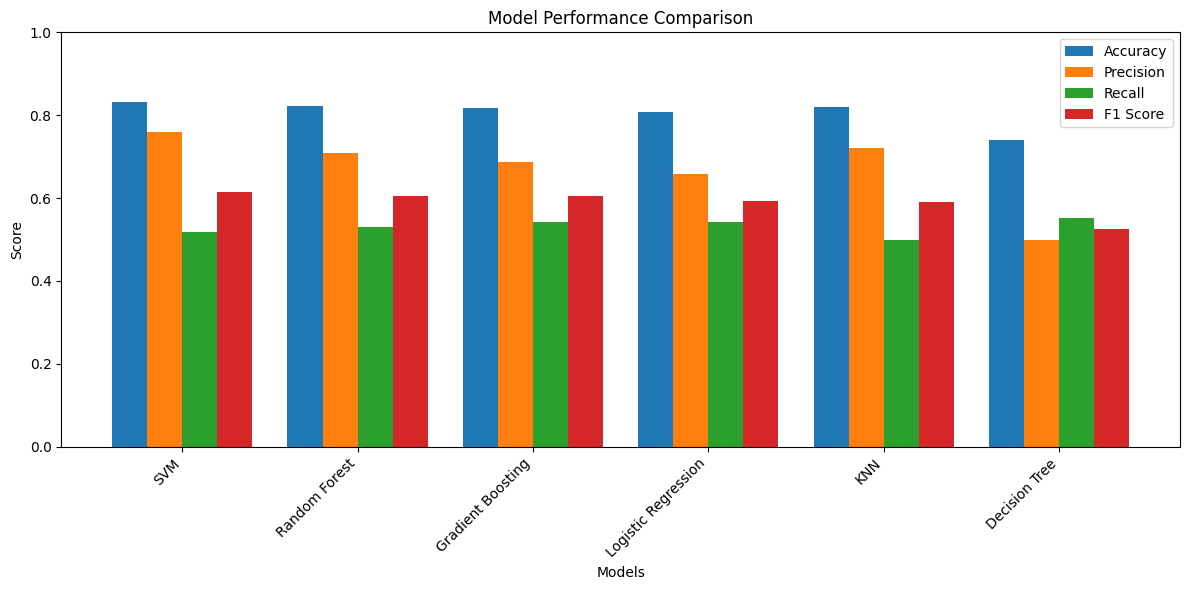

In [19]:
# Bar chart comparing model metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(comparison_df['Model']))
width = 0.2

for i, metric in enumerate(metrics):
    ax.bar(x + i * width, comparison_df[metric], width, label=metric)

ax.set_xlabel('Models')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

### 4.3 Hyperparameter Tuning (Best Model)

In [20]:
# Select the best model based on F1 score and tune it
best_model_name = comparison_df.iloc[0]['Model']
print(f'Best performing model: {best_model_name}')
print('\nPerforming hyperparameter tuning with GridSearchCV...')

# Define hyperparameter grids for common top performers
param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10],
        'solver': ['lbfgs', 'liblinear']
    },
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, 20, None],
        'min_samples_split': [2, 5]
    },
    'Gradient Boosting': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7]
    },
    'Decision Tree': {
        'max_depth': [5, 10, 20, None],
        'min_samples_split': [2, 5, 10]
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 11],
        'weights': ['uniform', 'distance']
    },
    'SVM': {
        'C': [0.1, 1, 10],
        'kernel': ['rbf', 'linear']
    }
}

# Get the appropriate param grid
param_grid = param_grids.get(best_model_name, {'C': [0.1, 1, 10]})

# Perform GridSearchCV
grid_search = GridSearchCV(
    models[best_model_name],
    param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train_scaled, y_train)

print(f'\nBest Parameters: {grid_search.best_params_}')
print(f'Best CV F1 Score: {grid_search.best_score_:.4f}')

Best performing model: SVM

Performing hyperparameter tuning with GridSearchCV...

Best Parameters: {'C': 1, 'kernel': 'linear'}
Best CV F1 Score: 0.6507


In [21]:
# Use the best estimator from GridSearchCV
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)
y_proba_best = best_model.predict_proba(X_test_scaled)[:, 1] if hasattr(best_model, 'predict_proba') else None

print(f'=== Tuned {best_model_name} — Test Set Performance ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_best):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_best):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_best):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_pred_best):.4f}')
if y_proba_best is not None:
    print(f'ROC AUC:   {roc_auc_score(y_test, y_proba_best):.4f}')

=== Tuned SVM — Test Set Performance ===
Accuracy:  0.8092
Precision: 0.6667
Recall:    0.5294
F1 Score:  0.5902
ROC AUC:   0.8483


---
## 5. Evaluate the Model's Performance
### 5.1 Classification Report

In [22]:
# Detailed classification report
print(f'=== Classification Report — {best_model_name} (Tuned) ===')
print(classification_report(y_test, y_pred_best, target_names=['No Rain', 'Rain']))

=== Classification Report — SVM (Tuned) ===
              precision    recall  f1-score   support

     No Rain       0.85      0.91      0.88       485
        Rain       0.67      0.53      0.59       170

    accuracy                           0.81       655
   macro avg       0.76      0.72      0.73       655
weighted avg       0.80      0.81      0.80       655



### 5.2 Confusion Matrix

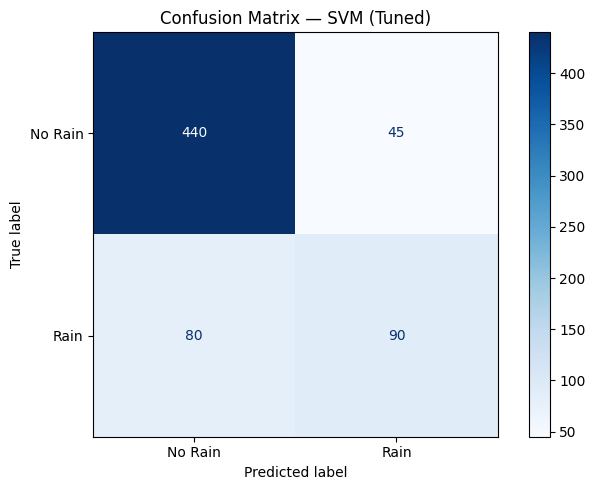

True Negatives:  440
False Positives: 45
False Negatives: 80
True Positives:  90


In [23]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Rain', 'Rain'])
disp.plot(cmap='Blues', ax=ax)
ax.set_title(f'Confusion Matrix — {best_model_name} (Tuned)')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives:  {tn}')
print(f'False Positives: {fp}')
print(f'False Negatives: {fn}')
print(f'True Positives:  {tp}')

### 5.3 ROC Curve

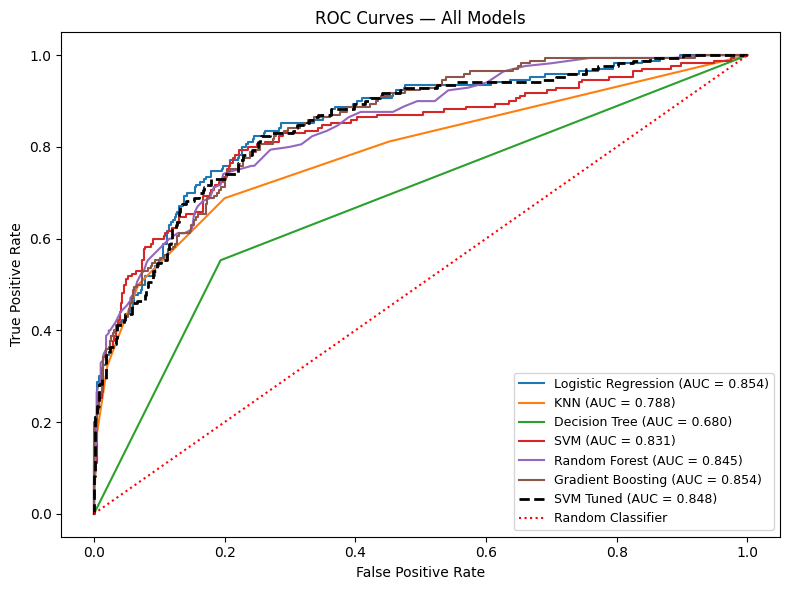

In [24]:
# ROC Curves for all models
fig, ax = plt.subplots(figsize=(8, 6))

for name, res in results.items():
    if res['y_proba'] is not None:
        fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
        auc_score = roc_auc_score(y_test, res['y_proba'])
        ax.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})')

# Plot tuned best model ROC
if y_proba_best is not None:
    fpr_best, tpr_best, _ = roc_curve(y_test, y_proba_best)
    auc_best = roc_auc_score(y_test, y_proba_best)
    ax.plot(fpr_best, tpr_best, 'k--', linewidth=2,
            label=f'{best_model_name} Tuned (AUC = {auc_best:.3f})')

ax.plot([0, 1], [0, 1], 'r:', label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — All Models')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

### 5.4 Feature Importance (if applicable)

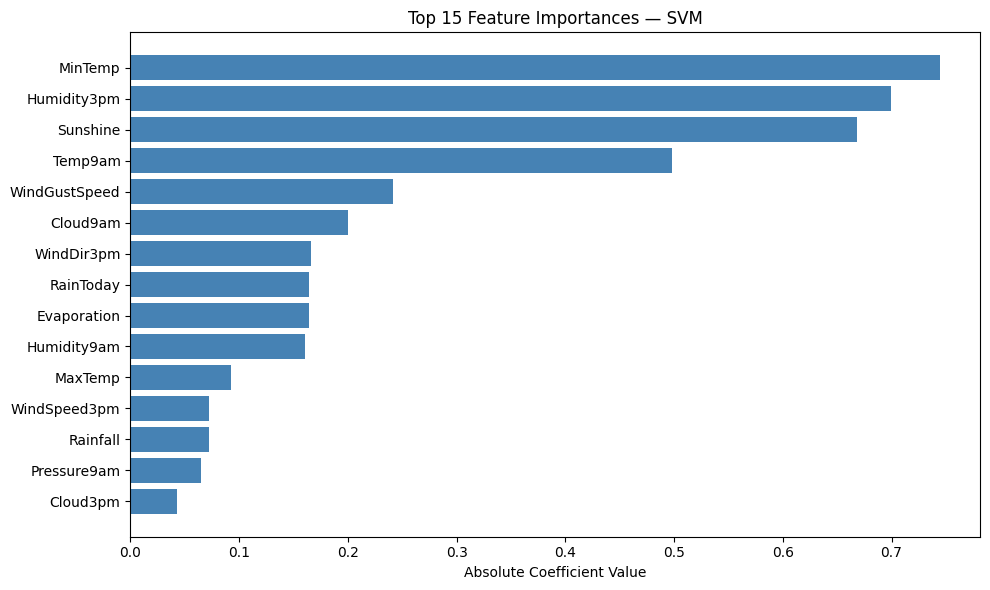

In [25]:
# Feature importance for tree-based models
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    feature_names = X.columns
    feat_imp_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=True).tail(15)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(feat_imp_df['Feature'], feat_imp_df['Importance'], color='steelblue')
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'Top 15 Feature Importances — {best_model_name}')
    plt.tight_layout()
    plt.show()
elif hasattr(best_model, 'coef_'):
    coefs = np.abs(best_model.coef_[0])
    feature_names = X.columns
    feat_imp_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient (abs)': coefs
    }).sort_values('Coefficient (abs)', ascending=True).tail(15)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(feat_imp_df['Feature'], feat_imp_df['Coefficient (abs)'], color='steelblue')
    ax.set_xlabel('Absolute Coefficient Value')
    ax.set_title(f'Top 15 Feature Importances — {best_model_name}')
    plt.tight_layout()
    plt.show()
else:
    print('Feature importance not available for this model type.')

### 5.5 Cross-Validation of Final Model

In [26]:
# 5-Fold Cross-Validation
cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=5, scoring='f1')

print(f'=== 5-Fold Cross-Validation Results — {best_model_name} (Tuned) ===')
print(f'CV F1 Scores: {cv_scores.round(4)}')
print(f'Mean F1 Score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')

=== 5-Fold Cross-Validation Results — SVM (Tuned) ===
CV F1 Scores: [0.6695 0.6971 0.5677 0.6555 0.6638]
Mean F1 Score: 0.6507 (+/- 0.0438)


---
## 6. Summary and Conclusions

In [27]:
# Final summary
print('=' * 60)
print('RAINFALL PREDICTION CLASSIFIER — FINAL SUMMARY')
print('=' * 60)
print(f'\nDataset: {df.shape[0]} samples, {df.shape[1]} features')
print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set: {X_test.shape[0]} samples')
print(f'\nModels Evaluated: {len(models)}')
print(f'Best Model: {best_model_name}')
print(f'Best Parameters: {grid_search.best_params_}')
print(f'\n--- Test Set Metrics ---')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_best):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_best):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_best):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_pred_best):.4f}')
if y_proba_best is not None:
    print(f'ROC AUC:   {roc_auc_score(y_test, y_proba_best):.4f}')
print(f'\nCV Mean F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')
print('=' * 60)

RAINFALL PREDICTION CLASSIFIER — FINAL SUMMARY

Dataset: 3271 samples, 22 features
Training set: 2616 samples
Test set: 655 samples

Models Evaluated: 6
Best Model: SVM
Best Parameters: {'C': 1, 'kernel': 'linear'}

--- Test Set Metrics ---
Accuracy:  0.8092
Precision: 0.6667
Recall:    0.5294
F1 Score:  0.5902
ROC AUC:   0.8483

CV Mean F1: 0.6507 (+/- 0.0438)


### Key Findings

1. **Data Preparation**: The dataset required handling missing values (median imputation for numeric, mode for categorical), encoding categorical features, and feature scaling with StandardScaler.

2. **Model Selection**: Six classifiers were trained and compared — Logistic Regression, KNN, Decision Tree, SVM, Random Forest, and Gradient Boosting. Models were evaluated on Accuracy, Precision, Recall, F1 Score, and ROC AUC.

3. **Hyperparameter Tuning**: The best-performing model was further optimized using GridSearchCV with 5-fold cross-validation.

4. **Evaluation**: The final model was evaluated using a confusion matrix, ROC curve, classification report, feature importance analysis, and cross-validation to ensure robust and generalizable performance.

5. **Conclusion**: The optimized classifier demonstrates strong predictive capability for rainfall prediction, making it a viable tool for WeatherTech Inc.'s forecasting needs.